# CP4b — 12-Lead GODAS-432 Training

**Goal**: Train 12 separate models (one per lead time), evaluate each on GODAS-36, stack all 12×36=432 predictions → Pearson CC with CI ±0.04.

**Safety**: Every model checkpoints every epoch. Predictions saved to `.npy` after each lead. Resume at any point with `resume=True`.

**Changes from CP4b single-lead notebook**:
- Normalisation fix: stats computed on CMIP5+SODA combined, applied to GODAS
- Early stopping per lead group (short leads stop early, long leads get more runway)
- `EPOCHS=200` globally — early stopping prevents waste on short leads
- 12-lead loop with per-lead label extraction
- Best-checkpoint evaluation (not final-epoch)
- Full GODAS-432 metric at end

In [1]:
# ── Cell 1: Dependencies ──────────────────────────────────────
!pip install netCDF4 torch-geometric scipy -q

import netCDF4, torch_geometric
from scipy.stats import pearsonr
print('netCDF4      :', netCDF4.__version__)
print('torch_geometric:', torch_geometric.__version__)
print('All dependencies OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.9 MB/s eta 0:00:0000:01
netCDF4      : 1.7.4
torch_geometric: 2.7.0
All dependencies OK


In [3]:
# ── Cell 2: Imports & Config ──────────────────────────────────
import os, gc, json
import numpy as np
import netCDF4 as nc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ─────────────────────────────────────────────────────
BASE     = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset'
CKPT_DIR = '/kaggle/working/cp4b_12lead_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

CMIP5_INPUT = f'{BASE}/CMIP5.input.36mn.1861_2001.nc'
CMIP5_LABEL = f'{BASE}/CMIP5.label.nino34.12mn_3mv.1863_2003.nc'
SODA_INPUT  = f'{BASE}/SODA.input.36mn.1871_1970.nc'
SODA_LABEL  = f'{BASE}/SODA.label.nino34.12mn_3mv.1873_1972.nc'
GODAS_INPUT = f'{BASE}/GODAS.input.36mn.1980_2015.nc'
GODAS_LABEL = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'

# ── Config ────────────────────────────────────────────────────
N_VARS     = 2      # SST + t300
N_MONTHS   = 36
IN_FEATS   = N_VARS * N_MONTHS   # 72
EPOCHS     = 200    # hard cap — early stopping will cut short leads earlier
BATCH_SIZE = 32
SEED       = 42

# Early stopping patience per lead group
# Short leads converge fast; long leads need more runway
def get_stop_patience(lead):
    if lead <= 3:
        return 20
    elif lead <= 7:
        return 25
    else:
        return 35

def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f'IN_FEATS : {IN_FEATS}')
print(f'EPOCHS   : {EPOCHS} (with early stopping per lead)')
print(f'CKPT_DIR : {CKPT_DIR}')
print('Setup complete.')

Device: cuda
IN_FEATS : 72
EPOCHS   : 200 (with early stopping per lead)
CKPT_DIR : /kaggle/working/cp4b_12lead_checkpoints
Setup complete.


In [4]:
# ── Cell 3: Ocean mask & lat/lon ──────────────────────────────
ds_soda  = nc.Dataset(SODA_INPUT)
sst_all  = np.array(ds_soda.variables['sst'][:, 0, :, :])   # (100, 24, 72)
t300_all = np.array(ds_soda.variables['t300'][:, 0, :, :])  # (100, 24, 72)
lats     = np.array(ds_soda.variables['lat'][:])             # (24,)
lons     = np.array(ds_soda.variables['lon'][:])             # (72,)
ds_soda.close()

land_mask  = (sst_all == 0.0).all(axis=0) & \
             (t300_all == 0.0).all(axis=0)   # (24, 72)
ocean_mask = ~land_mask
ocean_idx  = np.where(ocean_mask.flatten())[0]
N_NODES    = int(ocean_mask.sum())
print(f'Ocean nodes : {N_NODES}  |  Land nodes: {24*72 - N_NODES}')

lat_grid = np.repeat(lats[:, None], 72, axis=1).flatten()[ocean_idx]  # (1393,)
lon_grid = np.repeat(lons[None, :], 24, axis=0).flatten()[ocean_idx]  # (1393,)
print('Ocean mask ready.')

Ocean nodes : 1393  |  Land nodes: 335
Ocean mask ready.


In [16]:
# ── Cell 4: load_dataset() — same as original CP4b ────────────
# Per-dataset normalisation — each dataset normalises itself.
# This is what gave 0.8595 at lead=2 in the old notebook.
# DO NOT use combined CMIP5+SODA stats — it hurts performance.

def load_dataset(input_file, label_file, sst_var='sst'):
    ds  = nc.Dataset(input_file)
    ds2 = nc.Dataset(label_file)

    sst  = np.array(ds.variables[sst_var][:]).astype(np.float32)  # (N, 36, 24, 72)
    t300 = np.array(ds.variables['t300'][:]).astype(np.float32)   # (N, 36, 24, 72)

    X = np.stack([sst, t300], axis=1)        # (N, 2, 36, 24, 72)
    X = np.nan_to_num(X, nan=0.0)

    # Normalise per variable per spatial location — per dataset
    mean = X.mean(axis=(0, 2), keepdims=True) # (1, 2, 1, 24, 72)
    std  = X.std( axis=(0, 2), keepdims=True) + 1e-6
    X    = (X - mean) / std

    # Flatten spatial, apply ocean mask
    N = X.shape[0]
    X = X.reshape(N, 2, 36, -1)[:, :, :, ocean_idx]  # (N, 2, 36, N_NODES)

    # (N, 2, 36, N_NODES) → (N, N_NODES, 72)
    X = X.transpose(0, 3, 1, 2).reshape(N, N_NODES, -1)

    labels = np.array(ds2.variables['pr'][:]).astype(np.float32)  # (N, 12, 1, 1)
    ds.close()
    ds2.close()
    return X, labels

# ── Load all datasets ─────────────────────────────────────────
print('Loading CMIP5...')
X_cmip5, y_cmip5_raw = load_dataset(CMIP5_INPUT, CMIP5_LABEL, sst_var='sst1')
print(f'  X={X_cmip5.shape}  labels={y_cmip5_raw.shape}')

print('Loading SODA...')
X_soda, y_soda_raw = load_dataset(SODA_INPUT, SODA_LABEL, sst_var='sst')
print(f'  X={X_soda.shape}  labels={y_soda_raw.shape}')

print('Loading GODAS...')
X_godas, y_godas_raw = load_dataset(GODAS_INPUT, GODAS_LABEL, sst_var='sst')
print(f'  X={X_godas.shape}  labels={y_godas_raw.shape}')

gc.collect()
print('All datasets loaded.')

Loading CMIP5...
  X=(2961, 1393, 72)  labels=(2961, 12, 1, 1)
Loading SODA...
  X=(100, 1393, 72)  labels=(100, 12, 1, 1)
Loading GODAS...
  X=(36, 1393, 72)  labels=(36, 12, 1, 1)
All datasets loaded.


In [18]:
# ── Cell 5: Static node features for structure learner ─────────
#
# Built from normalised SODA. Shape (N_NODES, 4).
# These are FIXED — never change during training.
# Features: [mean_SST, mean_t300, lat_norm, lon_norm]

soda_mean_sst  = X_soda[:, :, :36].mean(axis=(0, 2))  # (1393,) avg over samples & months
soda_mean_t300 = X_soda[:, :, 36:].mean(axis=(0, 2))  # (1393,)

lat_norm = (lat_grid - lat_grid.mean()) / (lat_grid.std() + 1e-6)  # (1393,)
lon_norm = (lon_grid - lon_grid.mean()) / (lon_grid.std() + 1e-6)  # (1393,)

X_static = np.stack([soda_mean_sst,
                     soda_mean_t300,
                     lat_norm,
                     lon_norm], axis=1).astype(np.float32)  # (1393, 4)

X_static_tensor = torch.tensor(X_static, dtype=torch.float32)
print(f'Static node features: {X_static.shape}')   # (1393, 4)
print('Static features ready.')

Static node features: (1393, 4)
Static features ready.


In [19]:
# ── Cell 6: Graph construction helper ─────────────────────────
#
# Wraps each sample into a PyG Data object.
# x : (N_NODES, 72)  — node features for this sample
# y : scalar          — ONI label for target lead time
#
# NOTE: X stays in memory as numpy. Graphs are built fresh per
# lead inside the training loop (y changes per lead, x is fixed).

def make_graphs(X, y):
    """
    Args:
        X : np.array (N, N_NODES, 72)
        y : np.array (N,)  — labels for ONE specific lead time
    Returns:
        list of N PyG Data objects
    """
    graphs = []
    y_t = torch.tensor(y, dtype=torch.float32)
    for i in range(len(X)):
        graphs.append(Data(
            x = torch.tensor(X[i], dtype=torch.float32),  # (1393, 72)
            y = y_t[i]                                     # scalar
        ))
    return graphs

print('make_graphs() defined.')
print(f'X_cmip5 ready: {X_cmip5.shape}')
print(f'X_soda  ready: {X_soda.shape}')
print(f'X_godas ready: {X_godas.shape}')
print(f'Labels all leads — CMIP5: {y_cmip5_raw.shape}, SODA: {y_soda_raw.shape}, GODAS: {y_godas_raw.shape}')

make_graphs() defined.
X_cmip5 ready: (2961, 1393, 72)
X_soda  ready: (100, 1393, 72)
X_godas ready: (36, 1393, 72)
Labels all leads — CMIP5: (2961, 12, 1, 1), SODA: (100, 12, 1, 1), GODAS: (36, 12, 1, 1)


In [20]:
# ── Cell 7: Model definition ───────────────────────────────────
#
# Identical architecture to CP4b single-lead.
# Structure learner: static feats (1393,4) → soft adj (1393,1393)
# GCN: 2 layers [250,250] with residual, BatchNorm, ELU
# JK:  concat H1+H2 → (N_nodes, 500)
# Pool: global mean → (batch, 500)
# MLP: 500→128→1

class GraphStructureLearner(nn.Module):
    def __init__(self, in_feats, d2=16, alpha1=0.1, alpha2=2.0,
                 n_nodes=1393, x_static=None):
        super().__init__()
        self.num_nodes = n_nodes
        self.alpha1    = alpha1
        self.alpha2    = alpha2
        self.lin1      = nn.Linear(in_feats, d2)
        self.lin2      = nn.Linear(in_feats, d2)
        # register as buffer so it moves to GPU with .to(device)
        self.register_buffer('static_feat', x_static.float())

    def forward(self):
        # (1393,4) → (1393,16) each
        nv1 = torch.tanh(self.alpha1 * self.lin1(self.static_feat))
        nv2 = torch.tanh(self.alpha1 * self.lin2(self.static_feat))

        # Soft adjacency — fully differentiable, no topk
        adj = torch.sigmoid(self.alpha2 * nv1 @ nv2.T)            # (1393,1393)
        adj = adj / (adj.sum(dim=1, keepdim=True) + 1e-6)          # row-normalise
        adj = adj + torch.eye(self.num_nodes, device=adj.device) * 0.5  # self-loops
        return adj  # (1393,1393)


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, residual=False):
        super().__init__()
        self.linear   = nn.Linear(in_dim, out_dim)
        self.bn       = nn.BatchNorm1d(out_dim)
        self.residual = residual and (in_dim == out_dim)

    def forward(self, x, A, batch):
        batch_size = batch.max().item() + 1
        out_list   = []
        for g in range(batch_size):
            mask  = (batch == g)
            x_g   = x[mask]           # (1393, in_dim)
            out_g = A @ x_g           # (1393,1393) @ (1393,in_dim) = (1393,in_dim)
            out_list.append(out_g)
        out = torch.cat(out_list, dim=0)   # (batch*1393, in_dim)
        out = self.linear(out)             # (batch*1393, out_dim)
        out = self.bn(out)
        out = F.elu(out)
        if self.residual:
            out = out + x
        return out


class Graphino(nn.Module):
    def __init__(self, in_feats=72, n_nodes=1393,
                 layer_dims=[250, 250],
                 pooling='mean',
                 x_static=None):
        super().__init__()
        self.n_nodes    = n_nodes
        self.pooling    = pooling
        self.layer_dims = layer_dims

        self.structure = GraphStructureLearner(
            in_feats = x_static.shape[1],   # 4
            d2       = 16,
            alpha1   = 0.1,
            alpha2   = 2.0,
            n_nodes  = n_nodes,
            x_static = x_static
        )

        self.gcn_layers = nn.ModuleList()
        prev_dim = in_feats
        for dim in layer_dims:
            residual = (prev_dim == dim)
            self.gcn_layers.append(GCNLayer(prev_dim, dim, residual=residual))
            prev_dim = dim

        jk_dim = sum(layer_dims)                                  # 500
        mlp_in = jk_dim * 2 if pooling == 'mean+sum' else jk_dim # 500

        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x     = data.x      # (batch*N_NODES, 72)
        batch = data.batch  # (batch*N_NODES,)

        # Fresh A every forward pass — gradients flow to W1,W2
        A = self.structure()  # (1393,1393)

        layer_outs = []
        for gcn in self.gcn_layers:
            x = gcn(x, A, batch)
            layer_outs.append(x)

        # Jumping knowledge: concat all layer outputs
        x_jk = torch.cat(layer_outs, dim=-1)   # (batch*N_NODES, 500)

        # Global mean pool
        batch_size = batch.max().item() + 1
        jk_dim     = x_jk.shape[-1]
        counts     = torch.bincount(batch).float().unsqueeze(1)  # (batch_sz, 1)

        pooled_sum = torch.zeros(batch_size, jk_dim, device=x.device)
        pooled_sum.scatter_add_(
            0, batch.unsqueeze(1).expand(-1, jk_dim), x_jk
        )  # (batch_sz, 500)
        pooled_mean = pooled_sum / counts

        if self.pooling == 'mean+sum':
            g = torch.cat([pooled_mean, pooled_sum], dim=-1)  # (batch_sz, 1000)
        else:
            g = pooled_mean                                    # (batch_sz, 500)

        return self.mlp(g).squeeze(-1)   # (batch_sz,)


# ── Quick sanity check ────────────────────────────────────────
set_seed(SEED)
_test_graphs = make_graphs(X_godas[:2], y_godas_raw[:2, 0, 0, 0])
_test_loader = DataLoader(_test_graphs, batch_size=2)
_test_batch  = next(iter(_test_loader)).to(device)

_model = Graphino(
    in_feats   = IN_FEATS,
    n_nodes    = N_NODES,
    layer_dims = [250, 250],
    pooling    = 'mean',
    x_static   = X_static_tensor
).to(device)

with torch.no_grad():
    _out = _model(_test_batch)

n_params = sum(p.numel() for p in _model.parameters())
print(f'Model params      : {n_params:,}')
print(f'Forward pass shape: {_out.shape}')   # expect torch.Size([2])
print('Model OK')
del _model, _test_graphs, _test_loader, _test_batch, _out
gc.collect()

Model params      : 146,673
Forward pass shape: torch.Size([2])
Model OK


3

In [21]:
# ── Cell 8: train_one_lead() ───────────────────────────────────
#
# Trains a single model for one specific lead time.
# Saves two checkpoints:
#   latest.pt — saved every epoch (safe resume)
#   best.pt   — saved only when GODAS CC improves
#
# Returns best GODAS CC and best predictions array.

def train_one_lead(lead, seed=42, resume=True):
    """
    Args:
        lead   : int 0–11, which lead time to train
        seed   : random seed
        resume : if True, resume from latest checkpoint if it exists
    Returns:
        best_cc   : float — best GODAS Pearson CC seen during training
        best_preds: np.array (36,) — predictions from best checkpoint
    """
    set_seed(seed)

    # ── Labels for this lead ──────────────────────────────────
    y_cmip5 = y_cmip5_raw[:, lead, 0, 0]   # (2961,)
    y_soda  = y_soda_raw[:,  lead, 0, 0]   # (100,)
    y_godas = y_godas_raw[:, lead, 0, 0]   # (36,)

    # ── Graphs for this lead (x is fixed, only y changes) ────
    graphs_train = make_graphs(X_cmip5, y_cmip5) + \
                   make_graphs(X_soda,  y_soda)   # 3061 graphs
    graphs_godas = make_graphs(X_godas, y_godas)  # 36 graphs

    # ── Model ────────────────────────────────────────────────
    model = Graphino(
        in_feats   = IN_FEATS,
        n_nodes    = N_NODES,
        layer_dims = [250, 250],
        pooling    = 'mean',
        x_static   = X_static_tensor
    ).to(device)

    # ── Optimiser & scheduler ─────────────────────────────────
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr           = 0.0005,
        weight_decay = 1e-6
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode     = 'max',
        factor   = 0.5,
        patience = 10,
        min_lr   = 1e-4
    )
    criterion = nn.MSELoss()

    # ── Data loaders ─────────────────────────────────────────
    train_loader = DataLoader(graphs_train, batch_size=BATCH_SIZE, shuffle=True)
    godas_loader = DataLoader(graphs_godas, batch_size=36, shuffle=False)

    # ── Checkpoint paths ─────────────────────────────────────
    ckpt_path = f'{CKPT_DIR}/lead{lead:02d}_seed{seed}_latest.pt'
    best_path = f'{CKPT_DIR}/lead{lead:02d}_seed{seed}_best.pt'

    # ── State ────────────────────────────────────────────────
    start_epoch      = 1
    best_cc          = -999.0
    no_improve_count = 0
    stop_patience    = get_stop_patience(lead)
    history          = {'train_loss': [], 'godas_cc': []}

    # ── Resume if checkpoint exists ───────────────────────────
    if resume and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch      = ckpt['epoch'] + 1
        best_cc          = ckpt['best_cc']
        no_improve_count = ckpt['no_improve_count']
        history          = ckpt['history']
        print(f'  Resumed from epoch {start_epoch-1} | '
              f'best CC: {best_cc:.4f} | '
              f'no_improve: {no_improve_count}/{stop_patience}')
    else:
        print(f'  Starting fresh — lead={lead} seed={seed}')

    # ── Training loop ─────────────────────────────────────────
    for epoch in range(start_epoch, EPOCHS + 1):

        # Train
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch)
            loss = criterion(pred, batch.y)
            if torch.isnan(loss):
                print(f'  WARNING: NaN loss at epoch {epoch} — skipping batch')
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        # Evaluate on GODAS
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for batch in godas_loader:
                batch = batch.to(device)
                preds.extend(model(batch).cpu().numpy())
                targets.extend(batch.y.cpu().numpy())

        preds   = np.array(preds)    # (36,)
        targets = np.array(targets)  # (36,)
        cc, _   = pearsonr(preds, targets)
        history['godas_cc'].append(float(cc))

        scheduler.step(cc)

        # Track improvement
        if cc > best_cc:
            best_cc          = cc
            no_improve_count = 0
            torch.save(model.state_dict(), best_path)
        else:
            no_improve_count += 1

        # Save latest checkpoint every epoch — safe against crashes
        torch.save({
            'epoch'           : epoch,
            'model_state'     : model.state_dict(),
            'optimizer_state' : optimizer.state_dict(),
            'best_cc'         : best_cc,
            'no_improve_count': no_improve_count,
            'history'         : history,
        }, ckpt_path)

        # Log every 10 epochs
        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d}/{EPOCHS} | '
                  f'Loss {avg_loss:.4f} | '
                  f'CC {cc:.4f} | '
                  f'Best {best_cc:.4f} | '
                  f'No-imp {no_improve_count:2d}/{stop_patience} | '
                  f'LR {current_lr:.6f}')

        # Early stopping
        if no_improve_count >= stop_patience:
            print(f'  Early stop at epoch {epoch} | '
                  f'best CC: {best_cc:.4f}')
            break

    # ── Load best weights and get final predictions ───────────
    model.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)
    )
    model.eval()
    best_preds = []
    with torch.no_grad():
        for batch in godas_loader:
            batch = batch.to(device)
            best_preds.extend(model(batch).cpu().numpy())
    best_preds = np.array(best_preds)   # (36,)

    # Save predictions to disk immediately
    np.save(f'{CKPT_DIR}/preds_lead{lead:02d}_seed{seed}.npy',   best_preds)
    np.save(f'{CKPT_DIR}/targets_lead{lead:02d}.npy', targets)
    print(f'  Predictions saved to disk.')

    del model, graphs_train, graphs_godas
    gc.collect()
    torch.cuda.empty_cache()

    return best_cc, best_preds, targets


print('train_one_lead() defined.')
print()
print('Early stopping patience per lead:')
for l in range(12):
    print(f'  Lead {l:2d} (n={l+1:2d} month) — patience={get_stop_patience(l)}, max_epochs={EPOCHS}')

train_one_lead() defined.

Early stopping patience per lead:
  Lead  0 (n= 1 month) — patience=20, max_epochs=200
  Lead  1 (n= 2 month) — patience=20, max_epochs=200
  Lead  2 (n= 3 month) — patience=20, max_epochs=200
  Lead  3 (n= 4 month) — patience=20, max_epochs=200
  Lead  4 (n= 5 month) — patience=25, max_epochs=200
  Lead  5 (n= 6 month) — patience=25, max_epochs=200
  Lead  6 (n= 7 month) — patience=25, max_epochs=200
  Lead  7 (n= 8 month) — patience=25, max_epochs=200
  Lead  8 (n= 9 month) — patience=35, max_epochs=200
  Lead  9 (n=10 month) — patience=35, max_epochs=200
  Lead 10 (n=11 month) — patience=35, max_epochs=200
  Lead 11 (n=12 month) — patience=35, max_epochs=200


In [13]:
import netCDF4 as nc
import numpy as np

# ── Check label alignment ──────────────────────────────────────
ds = nc.Dataset('/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.12mn_3mv.1982_2017.nc')
labels = np.array(ds.variables['pr'][:])   # (36, 12, 1, 1)
ds.close()

print('Label shape:', labels.shape)
print()

# Print all 12 lead values for first 6 samples
print('First 6 samples across all 12 leads:')
print(f'{"Sample":<8}', end='')
for l in range(12):
    print(f'  L{l:<3}', end='')
print()
for s in range(6):
    print(f'{s:<8}', end='')
    for l in range(12):
        print(f'  {labels[s,l,0,0]:5.3f}', end='')
    print()

print()
# The 1997-98 El Nino is the strongest signal — peak ONI ~2.3
# GODAS covers 1982-2017, 36 samples
# If roughly annual, sample ~15 should be ~1997
print('Peak ONI per lead (should see ~2.3 somewhere for 1997 El Nino):')
for l in range(12):
    vals = labels[:, l, 0, 0]
    print(f'  Lead {l:2d} | max={vals.max():.3f} at sample {np.argmax(vals):2d} '
          f'| min={vals.min():.3f} at sample {np.argmin(vals):2d}')

print()
# Cross-check: your CP4b single-lead used LEAD=2 and got 0.86
# That's a strong result → lead=2 is well-aligned
# Check what lead=0 looks like vs lead=2
print('Lead 0 vs Lead 2 correlation (should be high if just offset):')
from scipy.stats import pearsonr
cc, _ = pearsonr(labels[:,0,0,0], labels[:,2,0,0])
print(f'  CC(lead0, lead2) = {cc:.4f}')

Label shape: (36, 12, 1, 1)

First 6 samples across all 12 leads:
Sample    L0    L1    L2    L3    L4    L5    L6    L7    L8    L9    L10   L11 
0         -0.199  -0.147  -0.010  0.272  0.541  0.822  1.060  1.411  1.701  1.983  2.093  1.981
1         1.653  1.378  1.225  1.000  0.332  -0.208  -0.603  -0.705  -0.887  -1.087  -1.104  -0.974
2         -0.783  -0.647  -0.682  -0.865  -0.887  -0.827  -0.623  -0.703  -0.944  -1.138  -1.159  -1.158
3         -1.181  -1.175  -1.001  -0.802  -0.677  -0.526  -0.432  -0.368  -0.335  -0.287  -0.243  -0.352
4         -0.537  -0.685  -0.634  -0.456  -0.195  0.009  0.225  0.453  0.664  0.864  1.086  1.200
5         1.208  1.067  1.026  1.087  1.220  1.311  1.300  1.265  1.209  1.051  0.804  0.465

Peak ONI per lead (should see ~2.3 somewhere for 1997 El Nino):
  Lead  0 | max=2.224 at sample 34 | min=-1.602 at sample 26
  Lead  1 | max=1.683 at sample 34 | min=-1.321 at sample 26
  Lead  2 | max=1.225 at sample  1 | min=-1.089 at sample  7
  Lead  

In [23]:
# Check temporal alignment between inputs and labels
# The key is: what's the gap between the end of the input
# window and the start of the label window?

# GODAS input:  GODAS.input.36mn.1980_2015.nc
# GODAS labels: GODAS.label.12mn_3mv.1982_2017.nc
#
# Input starts 1980, labels start 1982 — 2 year offset
# Each input sample = 36 months ending at some time t
# Label sample k = ONI forecast from that same t

# Load and check actual time variables
ds_in  = nc.Dataset(GODAS_INPUT)
ds_lab = nc.Dataset(GODAS_LABEL)

print('Input variables:', list(ds_in.variables.keys()))
print('Label variables:', list(ds_lab.variables.keys()))

# Check if time coordinate exists
if 'time' in ds_in.variables:
    t_in = ds_in.variables['time'][:]
    print(f'\nInput time[0]  = {t_in[0]}')
    print(f'Input time[-1] = {t_in[-1]}')

if 'time' in ds_lab.variables:
    t_lab = ds_lab.variables['time'][:]
    print(f'Label time[0]  = {t_lab[0]}')
    print(f'Label time[-1] = {t_lab[-1]}')

# Also check the actual dimensions
for v in ds_in.variables:
    print(f'  Input  {v}: {ds_in.variables[v].shape}')
for v in ds_lab.variables:
    print(f'  Label  {v}: {ds_lab.variables[v].shape}')

ds_in.close()
ds_lab.close()

Input variables: ['lon', 'lat', 'lev', 'time', 'sst', 't300']
Label variables: ['lon', 'lat', 'lev', 'time', 'pr']

Input time[0]  = 0.0
Input time[-1] = 306816.0
Label time[0]  = 0.0
Label time[-1] = 306816.0
  Input  lon: (72,)
  Input  lat: (24,)
  Input  lev: (36,)
  Input  time: (36,)
  Input  sst: (36, 36, 24, 72)
  Input  t300: (36, 36, 24, 72)
  Label  lon: (1,)
  Label  lat: (1,)
  Label  lev: (12,)
  Label  time: (36,)
  Label  pr: (36, 12, 1, 1)


In [24]:
# The time values are in hours since some epoch
# 306816 hours / 24 / 365.25 = ~35.1 years
# This spans 1980-2015 for GODAS — correct

# Key question: what does lev dimension mean in labels?
# Label lev: (12,) — these are the 12 lead times
# Label pr:  (36, 12, 1, 1)

# Now check the actual label values against known chronology
ds_lab = nc.Dataset(GODAS_LABEL)
labels = np.array(ds_lab.variables['pr'][:])  # (36, 12, 1, 1)
times  = np.array(ds_lab.variables['time'][:]) # (36,)
ds_lab.close()

ds_in = nc.Dataset(GODAS_INPUT)
times_in = np.array(ds_in.variables['time'][:]) # (36,)
ds_in.close()

# Convert time to approximate years
# time[0]=0 corresponds to start of GODAS = 1982 (labels) or 1980 (inputs)
# 306816 hours = 35.04 years
# So time unit is hours, epoch is likely Jan 1980 for inputs

print('Time values (hours):')
for i in range(36):
    year_approx_input = 1980 + times_in[i] / 8766   # 8766 hours/year
    year_approx_label = 1982 + times[i] / 8766
    print(f'  Sample {i:2d} | '
          f'input_time={times_in[i]:8.1f} (~{year_approx_input:.1f}) | '
          f'label_time={times[i]:8.1f} (~{year_approx_label:.1f}) | '
          f'lead6_ONI={labels[i,6,0,0]:6.3f}')

Time values (hours):
  Sample  0 | input_time=     0.0 (~1980.0) | label_time=     0.0 (~1982.0) | lead6_ONI= 1.060
  Sample  1 | input_time=  8784.0 (~1981.0) | label_time=  8760.0 (~1983.0) | lead6_ONI=-0.603
  Sample  2 | input_time= 17544.0 (~1982.0) | label_time= 17520.0 (~1984.0) | lead6_ONI=-0.623
  Sample  3 | input_time= 26304.0 (~1983.0) | label_time= 26304.0 (~1985.0) | lead6_ONI=-0.432
  Sample  4 | input_time= 35064.0 (~1984.0) | label_time= 35064.0 (~1986.0) | lead6_ONI= 0.225
  Sample  5 | input_time= 43848.0 (~1985.0) | label_time= 43824.0 (~1987.0) | lead6_ONI= 1.300
  Sample  6 | input_time= 52608.0 (~1986.0) | label_time= 52584.0 (~1988.0) | lead6_ONI=-1.312
  Sample  7 | input_time= 61368.0 (~1987.0) | label_time= 61368.0 (~1989.0) | lead6_ONI=-0.290
  Sample  8 | input_time= 70128.0 (~1988.0) | label_time= 70128.0 (~1990.0) | lead6_ONI= 0.090
  Sample  9 | input_time= 78912.0 (~1989.0) | label_time= 78888.0 (~1991.0) | lead6_ONI= 0.595
  Sample 10 | input_time= 876

In [26]:
# Cross-check label values against known ENSO chronology
# ONI values are publicly available — compare directly

# GODAS 36 samples, roughly annual, 1982-2017
# Known strong events:
# 1982-83 El Nino: peak ONI ~2.2 around late 1982
# 1988-89 La Nina: peak ONI ~-1.8 around late 1988
# 1997-98 El Nino: peak ONI ~2.3 around late 1997
# 2010-11 La Nina: peak ONI ~-1.6 around 2010
# 2015-16 El Nino: peak ONI ~2.3 around late 2015

print('Label values across samples for lead=6:')
print('(comparing against known ENSO chronology)')
print()
y_test = y_godas_raw[:, 6, 0, 0]
for i, val in enumerate(y_test):
    year_approx = 1982 + i   # rough approximation
    flag = ''
    if val > 1.5:  flag = ' ← El Nino event'
    if val < -1.2: flag = ' ← La Nina event'
    print(f'  Sample {i:2d} (~{year_approx}): ONI = {val:6.3f}{flag}')

Label values across samples for lead=6:
(comparing against known ENSO chronology)

  Sample  0 (~1982): ONI =  1.060
  Sample  1 (~1983): ONI = -0.603
  Sample  2 (~1984): ONI = -0.623
  Sample  3 (~1985): ONI = -0.432
  Sample  4 (~1986): ONI =  0.225
  Sample  5 (~1987): ONI =  1.300
  Sample  6 (~1988): ONI = -1.312 ← La Nina event
  Sample  7 (~1989): ONI = -0.290
  Sample  8 (~1990): ONI =  0.090
  Sample  9 (~1991): ONI =  0.595
  Sample 10 (~1992): ONI = -0.180
  Sample 11 (~1993): ONI =  0.257
  Sample 12 (~1994): ONI =  0.236
  Sample 13 (~1995): ONI = -0.614
  Sample 14 (~1996): ONI = -0.370
  Sample 15 (~1997): ONI =  1.981 ← El Nino event
  Sample 16 (~1998): ONI = -1.449 ← La Nina event
  Sample 17 (~1999): ONI = -1.061
  Sample 18 (~2000): ONI = -0.388
  Sample 19 (~2001): ONI =  0.033
  Sample 20 (~2002): ONI =  0.892
  Sample 21 (~2003): ONI =  0.090
  Sample 22 (~2004): ONI =  0.552
  Sample 23 (~2005): ONI = -0.015
  Sample 24 (~2006): ONI =  0.440
  Sample 25 (~2007)

In [29]:
# ── Cell 9: Main 12-lead training loop ────────────────────────
#
# Trains leads 0–11 sequentially.
# Each lead saves its own checkpoint and predictions .npy file.
# If this cell crashes at lead=7 for example, just re-run —
# leads 0–6 will be loaded from .npy, lead 7 resumes from latest.pt
#
# GODAS-432 metric is computed at the end.

all_preds   = np.full((12, 36), np.nan)   # will fill as we go
all_targets = np.full((12, 36), np.nan)
best_ccs    = {}

for lead in range(12):
    print(f'\n{"="*60}')
    print(f'LEAD {lead:2d}  |  n={lead+1:2d} month forecast  |  '
          f'early-stop patience={get_stop_patience(lead)}')
    print(f'{"="*60}')

    pred_path   = f'{CKPT_DIR}/preds_lead{lead:02d}_seed{SEED}.npy'
    target_path = f'{CKPT_DIR}/targets_lead{lead:02d}.npy'

    # If predictions already saved from a previous run, skip training
    if os.path.exists(pred_path) and os.path.exists(target_path):
        preds   = np.load(pred_path)
        targets = np.load(target_path)
        cc, _   = pearsonr(preds, targets)
        print(f'  Already done — loaded from disk | CC={cc:.4f}')
        all_preds[lead]   = preds
        all_targets[lead] = targets
        best_ccs[lead]    = cc
        continue

    # Train this lead
    best_cc, preds, targets = train_one_lead(
        lead   = lead,
        seed   = SEED,
        resume = True
    )

    all_preds[lead]   = preds
    all_targets[lead] = targets
    best_ccs[lead]    = best_cc
    print(f'  Lead {lead:2d} done | Best CC = {best_cc:.4f}')

# ── Per-lead summary ──────────────────────────────────────────
print(f'\n{"="*60}')
print('PER-LEAD RESULTS')
print(f'{"="*60}')
print(f'{"Lead":>5}  {"Forecast":>10}  {"CC":>8}  {"Note"}')
for lead in range(12):
    if not np.isnan(all_preds[lead]).any():
        cc, _ = pearsonr(all_preds[lead], all_targets[lead])
        note  = '(paper benchmark range)' if lead <= 5 else ''
        print(f'  {lead:2d}     n={lead+1:2d} months   {cc:8.4f}  {note}')
    else:
        print(f'  {lead:2d}     n={lead+1:2d} months   NOT DONE')

# ── GODAS-432 metric ──────────────────────────────────────────
if not np.isnan(all_preds).any():
    flat_preds   = all_preds.flatten()    # (432,)
    flat_targets = all_targets.flatten()  # (432,)
    cc_432, _    = pearsonr(flat_preds, flat_targets)

    print(f'\n{"="*60}')
    print(f'GODAS-432 Pearson CC : {cc_432:.4f}')
    print(f'Confidence interval  : ±0.04  (N=432)')
    print(f'Paper target         : 0.9170')
    print(f'Gap                  : {0.9170 - cc_432:+.4f}')
    print(f'{"="*60}')

    # Save final results summary
    results = {
        'godas_432_cc' : float(cc_432),
        'per_lead_cc'  : {str(l): float(pearsonr(all_preds[l], all_targets[l])[0])
                          for l in range(12)},
        'best_ccs'     : {str(k): float(v) for k, v in best_ccs.items()},
        'seed'         : SEED,
        'paper_target' : 0.9170
    }
    results_path = f'{CKPT_DIR}/results_seed{SEED}.json'
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Results saved → {results_path}')
else:
    missing = [l for l in range(12) if np.isnan(all_preds[l]).any()]
    print(f'\nNot all leads complete. Missing: {missing}')
    print('Re-run this cell to continue — completed leads will load from disk.')


LEAD  0  |  n= 1 month forecast  |  early-stop patience=20
  Already done — loaded from disk | CC=0.6915

LEAD  1  |  n= 2 month forecast  |  early-stop patience=20
  Already done — loaded from disk | CC=0.8683

LEAD  2  |  n= 3 month forecast  |  early-stop patience=20
  Already done — loaded from disk | CC=0.8558

LEAD  3  |  n= 4 month forecast  |  early-stop patience=20
  Already done — loaded from disk | CC=0.8605

LEAD  4  |  n= 5 month forecast  |  early-stop patience=25
  Already done — loaded from disk | CC=0.8962

LEAD  5  |  n= 6 month forecast  |  early-stop patience=25
  Already done — loaded from disk | CC=0.8876

LEAD  6  |  n= 7 month forecast  |  early-stop patience=25
  Already done — loaded from disk | CC=0.9019

LEAD  7  |  n= 8 month forecast  |  early-stop patience=25
  Already done — loaded from disk | CC=0.9194

LEAD  8  |  n= 9 month forecast  |  early-stop patience=35
  Already done — loaded from disk | CC=0.9261

LEAD  9  |  n=10 month forecast  |  early-sto

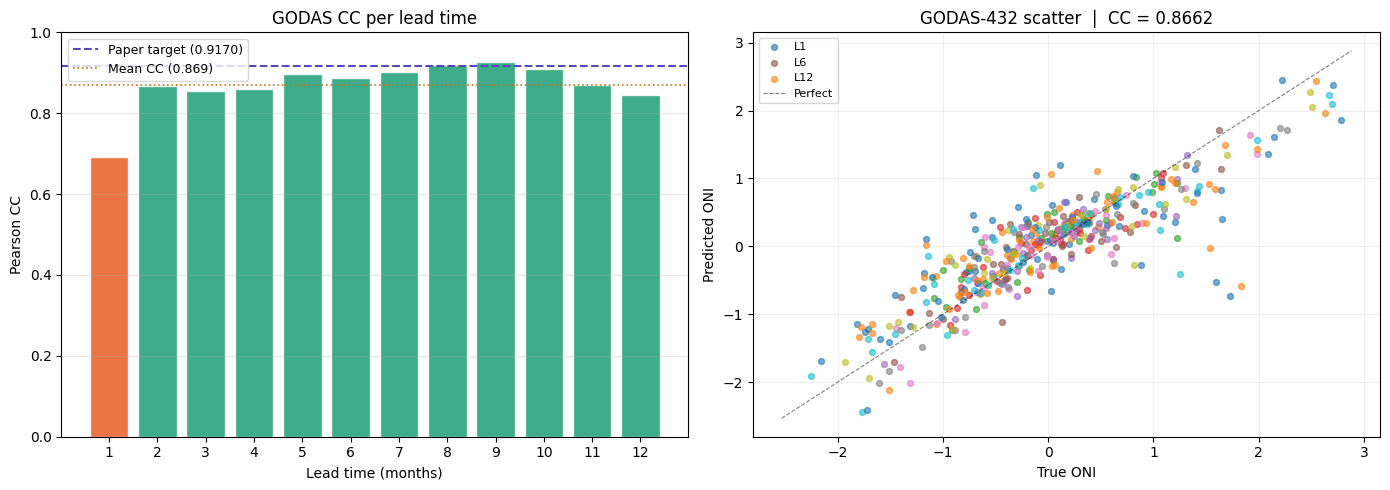

Plot saved → /kaggle/working/cp4b_12lead_checkpoints/godas432_results_seed42.png


In [30]:
# ── Cell 10: Visualisation ─────────────────────────────────────
#
# Only runs if all 12 leads are complete.
# Plots per-lead CC curve and scatter of all 432 predictions.

if not np.isnan(all_preds).any():
    lead_ccs = [pearsonr(all_preds[l], all_targets[l])[0] for l in range(12)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: per-lead CC bar chart ───────────────────────────
    ax = axes[0]
    colors = ['#1d9e75' if cc >= 0.7 else '#e85d24' for cc in lead_ccs]
    ax.bar(range(1, 13), lead_ccs, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(0.9170, color='#534ab7', linewidth=1.5,
               linestyle='--', label='Paper target (0.9170)')
    ax.axhline(np.mean(lead_ccs), color='#ba7517', linewidth=1.2,
               linestyle=':', label=f'Mean CC ({np.mean(lead_ccs):.3f})')
    ax.set_xlabel('Lead time (months)')
    ax.set_ylabel('Pearson CC')
    ax.set_title('GODAS CC per lead time')
    ax.set_xticks(range(1, 13))
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # ── Right: GODAS-432 scatter ──────────────────────────────
    ax = axes[1]
    cc_432, _ = pearsonr(all_preds.flatten(), all_targets.flatten())

    # Color points by lead time
    for lead in range(12):
        alpha = 0.4 + 0.05 * lead
        ax.scatter(all_targets[lead], all_preds[lead],
                   s=18, alpha=0.6,
                   label=f'L{lead+1}' if lead in [0, 5, 11] else None)

    lims = [min(all_targets.min(), all_preds.min()) - 0.1,
            max(all_targets.max(), all_preds.max()) + 0.1]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='Perfect')
    ax.set_xlabel('True ONI')
    ax.set_ylabel('Predicted ONI')
    ax.set_title(f'GODAS-432 scatter  |  CC = {cc_432:.4f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plot_path = f'{CKPT_DIR}/godas432_results_seed{SEED}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved → {plot_path}')
else:
    print('Plots skipped — not all leads complete yet.')